In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv("train.csv")

In [4]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
df["Survived"]=df["Survived"].astype("category")
df['Pclass']=df["Pclass"].astype("category")
df["Sex"]=df["Sex"].astype("category")
df["SibSp"]=df["SibSp"].astype("int32")
df["Parch"]=df["Parch"].astype("int32")
df["Embarked"]=df["Embarked"].astype("category")
df["Group Size"]=df["SibSp"]+df["Parch"]+1
df["Alone?"]=df["Group Size"].apply(lambda x:0 if x==1 else 1)

In [8]:
df["Alone?"]

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: Alone?, Length: 891, dtype: int64

In [9]:
df.drop(columns='PassengerId').duplicated().sum()

np.int64(0)

### Column to be used are 
### Features:Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
### Target: Survived

In [10]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Fare', ylabel='Count'>

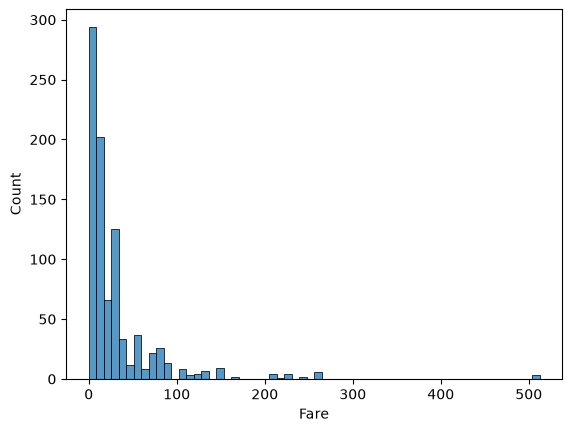

In [11]:
sns.histplot(df,x="Fare")

<Axes: xlabel='Survived', ylabel='Fare'>

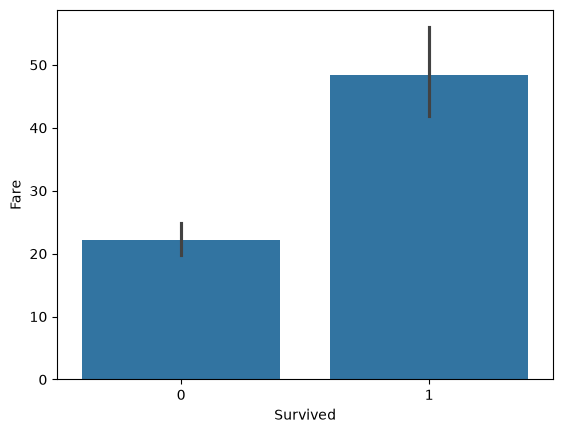

In [12]:
sns.barplot(df,x="Survived",y="Fare")

<Axes: xlabel='Survived', ylabel='SibSp'>

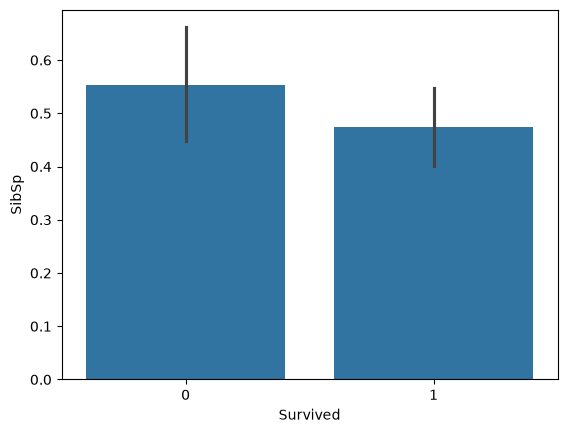

In [13]:
sns.barplot(df,x="Survived",y="SibSp")

In [14]:
df["Group Size"].value_counts()

Group Size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

<Axes: xlabel='Group Size', ylabel='count'>

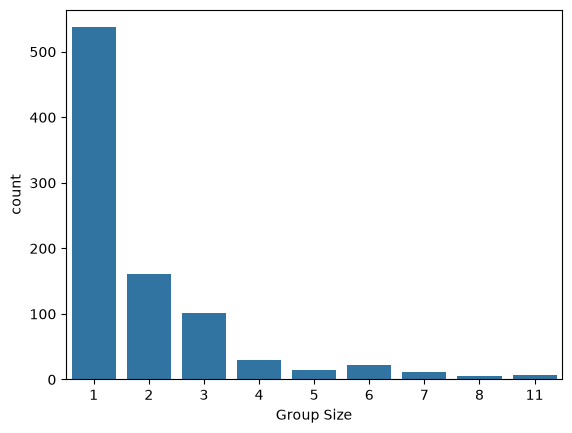

In [15]:
sns.countplot(x=df["Group Size"])

In [16]:
df[["Survived","SibSp"]]
#Not playing a big role

,Survived,SibSp
0,0,1
1,1,1
2,1,0
3,1,1
4,0,0
...,...,...
886,0,0
887,1,0
888,0,1
889,1,0


<Axes: xlabel='Survived', ylabel='Parch'>

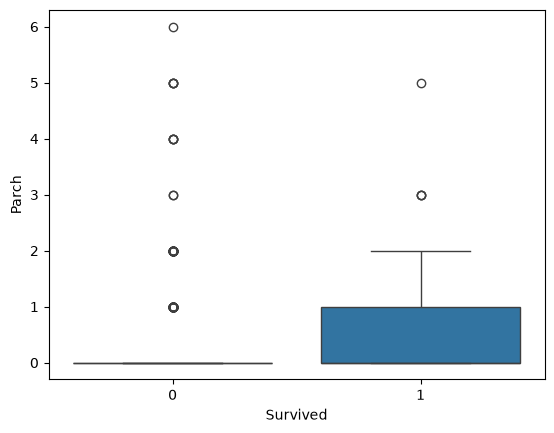

In [17]:
sns.boxplot(df,x="Survived",y="Parch")

<Axes: xlabel='Parch', ylabel='Count'>

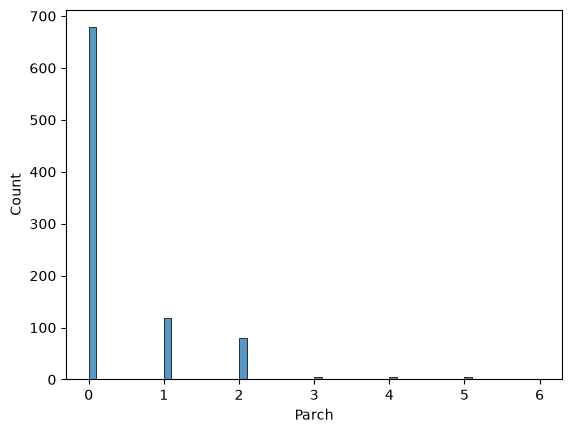

In [18]:
sns.histplot(x=df["Parch"])
#Has some outliers

In [19]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Group Size', 'Alone?'],
      dtype='str')

In [20]:
dt=df.pivot_table(index="Pclass",columns="Survived",values="Parch",aggfunc="count")

<Axes: xlabel='Survived', ylabel='Pclass'>

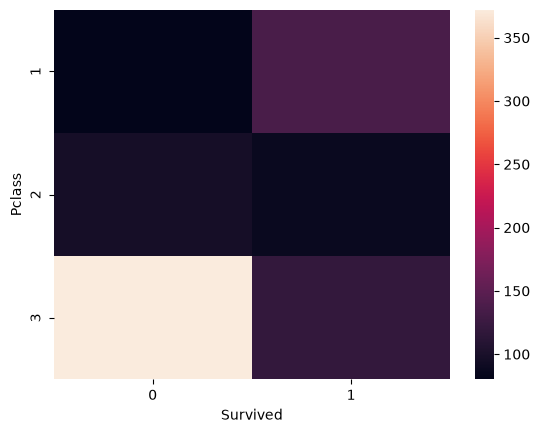

In [21]:
sns.heatmap(dt)
#for Pclass 1 the survived data is not linear

<Axes: xlabel='Sex', ylabel='Survived'>

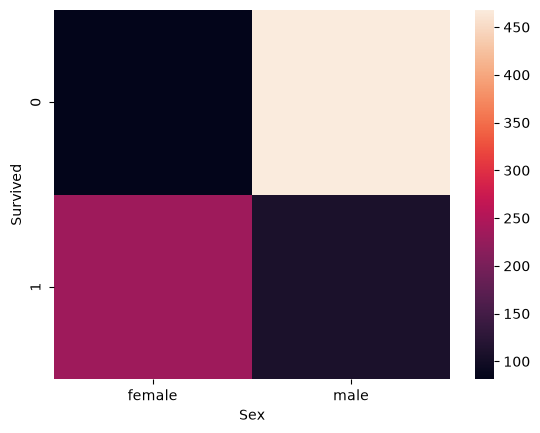

In [22]:
dt1=pd.pivot_table(df,index="Survived",columns="Sex",values="Pclass",aggfunc="count")
sns.heatmap(dt1)

<Axes: xlabel='Embarked', ylabel='Survived'>

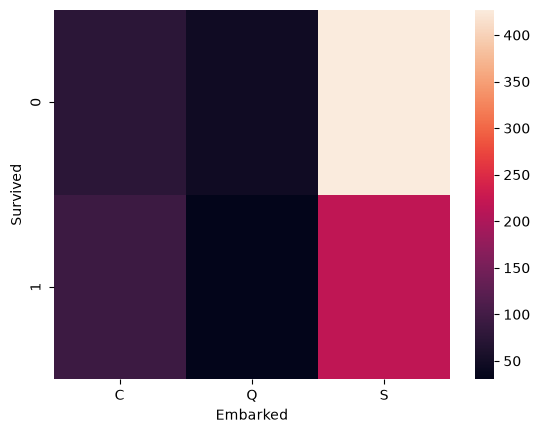

In [23]:
dt2=pd.pivot_table(df,index="Survived",columns="Embarked",values="Pclass",aggfunc="count")
sns.heatmap(dt2)

In [24]:
df["SibSp"].value_counts()
#Taking it as numerical 

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [25]:
df["Parch"].value_counts()
#This to as they are numerical and has ranking

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group Size,Alone?
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,0


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score
from sklearn.impute import SimpleImputer
from sklearn .svm import SVC

In [28]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Group Size', 'Alone?'],
      dtype='str')

In [29]:
X=df.drop(columns="Survived")
Y=df["Survived"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int32   
 7   Parch        891 non-null    int32   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    category
 12  Group Size   891 non-null    int32   
 13  Alone?       891 non-null    int64   
dtypes: category(4), float64(2), int32(3), int64(2), str(3)
memory usage: 63.1 KB


In [31]:
numericalColumn=['Age',"Group Size","SibSp",'Fare']
numPipeline=Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categoricalColumn=['Sex','Embarked','Pclass',"Alone?"]
catPipeline=Pipeline([("inputer",SimpleImputer(strategy="most_frequent")),("Encoder",OneHotEncoder())])
#Target col is alredy in proper form

In [32]:
# Pipeline for NB 
# Using columns not much related to each other
numcolumn=["Age",'Group Size',"Fare"]
cateCol=['Sex','Pclass',"Alone?"]
trf2=ColumnTransformer([("NumCol",numPipeline,numcolumn),("CatCol",catPipeline,cateCol)],remainder="drop")


In [33]:
trf=ColumnTransformer([("NumCol",numPipeline,numericalColumn),("CatCol",catPipeline,categoricalColumn)],remainder="drop")
lr=Pipeline([("trf",trf),("model",LogisticRegression(max_iter=1000))])


In [34]:
lr.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('trf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['PassengerId','Pclass','Name',...,'Embarked','Group Size','Alone?']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('NumCol', ...), ('CatCol', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remain

In [35]:
Y_pred=lr.predict(X_test)

In [36]:
confusion_matrix(Y_test,Y_pred)

array([[99, 11],
       [22, 47]])

In [37]:
f1_score(Y_test,Y_pred)

0.7401574803149606

In [38]:
from sklearn.naive_bayes import GaussianNB
nb=Pipeline([("ct",trf2),("Model",GaussianNB())])
nb.fit(X_train,Y_train)
y_pred2=nb.predict(X_test)
confusion_matrix(Y_test,y_pred2)

array([[87, 23],
       [18, 51]])

In [39]:
f1_score(Y_test,y_pred2)

0.7132867132867133

In [40]:
from sklearn.neighbors import KNeighborsClassifier
kn=Pipeline([("ct",trf2),("Model",KNeighborsClassifier(n_neighbors=3,metric="minkowski",p=2))])
kn.fit(X_train,Y_train)
Y_pred3=kn.predict(X_test)
confusion_matrix(Y_test,Y_pred3)

array([[96, 14],
       [19, 50]])

In [41]:
f1_score(Y_test,Y_pred3)
accuracy_score(Y_test,Y_pred3)

0.8156424581005587

## Support Vector Machine

In [42]:
svv=Pipeline([("PreProcessing",trf),("SupportVM",SVC(C=1,kernel="rbf",gamma="scale"))])
svv.fit(X_train,Y_train)
Y_pred4=svv.predict(X_test)
f1_score(Y_pred4,Y_test)

0.7258064516129032

## Trying Hyperparameter tuning

In [43]:
from sklearn.model_selection import GridSearchCV
gsp=Pipeline([("preProcessing",trf2),("model",KNeighborsClassifier(metric="minkowski"))])
paraGrid={
    "model__n_neighbors":[1,3,5,7,9,11],
    "model__p":[2,3,4,5,6]
}
gs=GridSearchCV(estimator=gsp,param_grid=paraGrid,cv=5,scoring="accuracy",n_jobs=-1)
gs.fit(X_train,Y_train)
gspPred=gs.predict(X_test)
accuracy_score(gspPred,Y_test)

0.7932960893854749

In [44]:
gs.best_params_

{'model__n_neighbors': 7, 'model__p': 4}

In [48]:
rs=RandomizedSearchCV(estimator=gsp,param_distributions=paraGrid,n_iter=10,cv=5,scoring="accuracy",n_jobs=-1)
rs.fit(X_train,Y_train)
rsPred=rs.predict(X_test)
accuracy_score(rsPred,Y_test)

0.7988826815642458